In [2]:
import pandas as pd
import numpy as np

# ТЗ

As a financial institution regulated by the FCA, %Company name% has the obligation to verify the identity of all customers who want to open a %Company name% account. Each prospective customer has to go through a Know Your Customer (KYC) process by submitting a government-issued photo ID and a facial picture of themselves to our partner, Veritas. Veritas then would perform 2 checks:

•  Document check: To verify that the photo ID is valid and authentic;
• Facial Similarity check: To verify that the face in the picture is the same with that on the submitted ID.

The customer will ‘pass’ the KYC process and get onboarded if the results of both Document and Facial Similarity checks are ‘clear’. If the result of any check is not ‘clear’, the customer has to submit all the photos again.

The “pass rate” is defined as the number of customers who pass both the KYC process divided by the number of customers who attempt the process. Each customer has up to 2 attempts.
The pass rate has decreased substantially in the recent period. 

Please write a report that outlines the root causes and suggest solutions.

Relevant files:
• Reports of all Facial Similarity checks
• Reports of all Document checks
• veritas.html - API documentation of Veritas explaining some terms used in the reports.

The candidate is free to use Excel or any scripting language to parse and analyse the data.
Please show all your work (including your code if applicable) and assumptions as well as provide a pdf / keynote with your findings (outcomes).

# Загружаем файлы

In [12]:
# https://drive.google.com/file/d/18ln2OUj3mB1U6l65fdHOtP-7ZzMzJ6Ms/view?usp=sharing
file_url_1 = 'https://drive.google.com/uc?export=download&id=18ln2OUj3mB1U6l65fdHOtP-7ZzMzJ6Ms'
# https://drive.google.com/file/d/1zJn51UnLPBMlPyG4mNNKcu-Vs5QP34IN/view?usp=sharing
file_url_2 = 'https://drive.google.com/uc?export=download&id=1zJn51UnLPBMlPyG4mNNKcu-Vs5QP34IN'
doc = pd.read_csv(file_url_1)
face = pd.read_csv(file_url_2)

In [14]:
doc.head()

,Unnamed: 0,user_id,result,visual_authenticity_result,image_integrity_result,face_detection_result,image_quality_result,created_at,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,attempt_id,police_record_result,compromised_document_result,properties,sub_result
0,27241,8190909e566647a5b6afeee9b4ec6c6a,clear,clear,clear,clear,clear,2017-05-25 08:38:56,clear,NaN,NaN,clear,NaN,clear,30e11e95e30748f485a2271ca5e6abb8,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear
1,28369,6b62136dfde348a99855e350294aaf5d,clear,clear,clear,clear,clear,2017-05-31 08:12:51,clear,NaN,NaN,clear,NaN,clear,4c0bfde8eb2249ed820e1f61d3ec3e33,clear,NaN,"{'gender': 'Male', 'document_type': 'driving_l...",clear
2,27988,73679363dccc46fa9f34a4fefd0d76e3,clear,clear,clear,clear,clear,2017-05-29 15:07:04,clear,NaN,NaN,clear,clear,clear,c5004fd1fc1d4e36a11433b70d960867,clear,NaN,"{'gender': 'Male', 'nationality': 'GBR', 'docu...",clear
3,27529,07857065dfa64db386739ec4fff47856,consider,clear,clear,clear,clear,2017-05-26 19:00:35,clear,NaN,NaN,clear,clear,consider,e4b26d4ddda545c9931a0a845cd65109,clear,NaN,"{'gender': 'Male', 'nationality': 'PER', 'docu...",caution
4,47987,9f887805b2af49069349ff107e0bca01,clear,clear,clear,clear,clear,2017-05-29 14:38:21,clear,NaN,NaN,clear,clear,clear,8ead2b23ef664e4d85fae798a7d5d52c,clear,NaN,"{'gender': 'Male', 'issuing_date': '2011-03', ...",clear


# Смотрим на doc

In [21]:
len(doc)

5880

In [29]:
#clear - проходят
#consider - не проходят

doc['result'].value_counts(normalize=True)

result
clear       0.74932
consider    0.25068
Name: proportion, dtype: float64

# Смотрим Nan

In [36]:
doc.isna().mean().sort_values(ascending=False)

data_comparison_result                0.985544
compromised_document_result           0.740816
data_consistency_result               0.485544
conclusive_document_quality_result    0.465986
colour_picture_result                 0.465986
data_validation_result                0.194048
police_record_result                  0.185204
face_detection_result                 0.151361
visual_authenticity_result            0.151190
supported_document_result             0.001871
properties                            0.000000
attempt_id                            0.000000
Unnamed: 0                            0.000000
user_id                               0.000000
created_at                            0.000000
image_quality_result                  0.000000
image_integrity_result                0.000000
result                                0.000000
sub_result                            0.000000
dtype: float64

# Смотрим даты

In [42]:
doc['created_at'] = pd.to_datetime(doc['created_at'], format='%Y-%m-%d %H:%M:%S')

In [46]:
doc['created_at'].agg(['min', 'max'])

min   2017-05-23 17:25:05
max   2017-10-31 22:06:10
Name: created_at, dtype: datetime64[ns]

# Преобразуем таргет в 1 и 0

In [52]:
doc['result_flag'] = doc['result'].apply(lambda row: 1 if row == 'consider' else 0)

In [59]:
doc['pass_rate'] = doc['result'].apply(lambda row: 1 if row == 'clear' else 0)

In [54]:
doc['result_flag'].mean()

0.2506802721088435

# Выделяем из даты месяц

In [69]:
doc['month'] = doc['created_at'].values.astype('datetime64[M]')

In [71]:
doc.groupby('month')['pass_rate'].agg(['count', 'mean'])

,count,mean
month,,
2017-05-01,58,0.965517
2017-06-01,276,0.967391
2017-07-01,1133,0.894086
2017-08-01,1228,0.828176
2017-09-01,1253,0.719074
2017-10-01,1932,0.596273


# Джоиним таблицы

`Процент успешной сдачи определяется как количество клиентов, прошедших оба этапа процедуры KYC, делённое на количество клиентов, попытавшихся пройти эту процедуру. У каждого клиента есть до двух попыток. Процент успешной сдачи значительно снизился за последний период.`

In [86]:
doc['user_id'].agg(['count', 'nunique'])

count      5880
nunique    5848
Name: user_id, dtype: int64

In [88]:
face['user_id'].agg(['count', 'nunique'])

count      5880
nunique    5848
Name: user_id, dtype: int64

In [84]:
df = doc.merge(face, how='left', on=['user_id', 'attempt_id'], suffixes=['_doc', '_face'])
df

,Unnamed: 0_doc,user_id,result_doc,visual_authenticity_result_doc,image_integrity_result,face_detection_result,image_quality_result,created_at_doc,supported_document_result,conclusive_document_quality_result,...,result_flag,month,pass_rate,Unnamed: 0_face,result_face,face_comparison_result,created_at_face,facial_image_integrity_result,visual_authenticity_result_face,properties_face
0,27241,8190909e566647a5b6afeee9b4ec6c6a,clear,clear,clear,clear,clear,2017-05-25 08:38:56,clear,NaN,...,0,2017-05-01,1,27241,consider,consider,2017-05-25 08:38:56,clear,clear,{'score': 0.42}
1,28369,6b62136dfde348a99855e350294aaf5d,clear,clear,clear,clear,clear,2017-05-31 08:12:51,clear,NaN,...,0,2017-05-01,1,28369,clear,clear,2017-05-31 08:12:51,clear,clear,{'score': 0.61}
2,27988,73679363dccc46fa9f34a4fefd0d76e3,clear,clear,clear,clear,clear,2017-05-29 15:07:04,clear,NaN,...,0,2017-05-01,1,27988,consider,NaN,2017-05-29 15:07:04,consider,clear,{}
3,27529,07857065dfa64db386739ec4fff47856,consider,clear,clear,clear,clear,2017-05-26 19:00:35,clear,NaN,...,1,2017-05-01,0,27529,clear,clear,2017-05-26 19:00:35,clear,clear,{'score': 0.65}
4,47987,9f887805b2af49069349ff107e0bca01,clear,clear,clear,clear,clear,2017-05-29 14:38:21,clear,NaN,...,0,2017-05-01,1,47987,clear,clear,2017-05-29 14:38:21,clear,clear,{'score': 0.59}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,80036,694894c1934646268e2502093c583849,clear,clear,clear,clear,clear,2017-10-04 13:41:55,clear,clear,...,0,2017-10-01,1,80036,clear,clear,2017-10-04 13:41:55,clear,clear,{}
5876,68019,b4c2ec7f7b18454eba27d6fa0e971bf9,consider,NaN,consider,NaN,unidentified,2017-10-25 11:36:18,clear,NaN,...,1,2017-10-01,0,68019,clear,clear,2017-10-25 11:36:18,clear,NaN,{}
5877,5896,ff977fd9fe9b4de7aff2548f2a27380b,clear,clear,clear,clear,clear,2017-10-29 15:07:49,clear,clear,...,0,2017-10-01,1,5896,clear,clear,2017-10-29 15:07:49,clear,clear,{}
5878,21409,997332eae0cc4becbdb14239c93ec38a,clear,clear,clear,clear,clear,2017-10-09 14:37:46,clear,clear,...,0,2017-10-01,1,21409,clear,clear,2017-10-09 14:37:46,clear,clear,{}


# Смотрим на повтор значений

In [114]:
df.groupby('user_id')['pass_rate'].count().sort_values(ascending=False)

user_id
f218379dd76b4058958450cb9aaea143    2
2e98fa65f2fe4d76a1ff0f30bd4048a9    2
76e5f56153ee4fbdb80372e2a6425622    2
527691d1867747d58a9357421f61a2b1    2
d05a9ec2f1a54c03942b6fc9fd6b44cc    2
                                   ..
5518f621031b4cf8a430cef0787a7bd9    1
55160178f712475991f2f68d46c6308b    1
5512d269423d41ca9061c88e41c54e48    1
55126b568c5e43b2a5eef3960fa9db52    1
fff6c1c8612d4f9d8a1d141a07beb8e3    1
Name: pass_rate, Length: 5848, dtype: int64

In [116]:
df[df['user_id'] == 'f218379dd76b4058958450cb9aaea143']

,Unnamed: 0_doc,user_id,result_doc,visual_authenticity_result_doc,image_integrity_result,face_detection_result,image_quality_result,created_at_doc,supported_document_result,conclusive_document_quality_result,...,result_flag,month,pass_rate,Unnamed: 0_face,result_face,face_comparison_result,created_at_face,facial_image_integrity_result,visual_authenticity_result_face,properties_face
780,166044,f218379dd76b4058958450cb9aaea143,consider,consider,clear,clear,clear,2017-07-20 15:39:32,clear,NaN,...,1,2017-07-01,0,166044,clear,clear,2017-07-20 15:39:32,clear,consider,{}
1406,165796,f218379dd76b4058958450cb9aaea143,clear,clear,clear,clear,clear,2017-07-20 18:46:48,clear,NaN,...,0,2017-07-01,1,165796,clear,clear,2017-07-20 18:46:48,clear,clear,{}


In [119]:
df.columns

Index(['Unnamed: 0_doc', 'user_id', 'result_doc',
       'visual_authenticity_result_doc', 'image_integrity_result',
       'face_detection_result', 'image_quality_result', 'created_at_doc',
       'supported_document_result', 'conclusive_document_quality_result',
       'colour_picture_result', 'data_validation_result',
       'data_consistency_result', 'data_comparison_result', 'attempt_id',
       'police_record_result', 'compromised_document_result', 'properties_doc',
       'sub_result', 'result_flag', 'month', 'pass_rate', 'Unnamed: 0_face',
       'result_face', 'face_comparison_result', 'created_at_face',
       'facial_image_integrity_result', 'visual_authenticity_result_face',
       'properties_face'],
      dtype='object')

# Перегружаем датасет

In [121]:
# https://drive.google.com/file/d/18ln2OUj3mB1U6l65fdHOtP-7ZzMzJ6Ms/view?usp=sharing
file_url_1 = 'https://drive.google.com/uc?export=download&id=18ln2OUj3mB1U6l65fdHOtP-7ZzMzJ6Ms'
# https://drive.google.com/file/d/1zJn51UnLPBMlPyG4mNNKcu-Vs5QP34IN/view?usp=sharing
file_url_2 = 'https://drive.google.com/uc?export=download&id=1zJn51UnLPBMlPyG4mNNKcu-Vs5QP34IN'
doc = pd.read_csv(file_url_1)
face = pd.read_csv(file_url_2)

In [125]:
df = doc.merge(face, how='left', on=['user_id', 'attempt_id'], suffixes=['_d', '_f'])
df

,Unnamed: 0_d,user_id,result_d,visual_authenticity_result_d,image_integrity_result,face_detection_result,image_quality_result,created_at_d,supported_document_result,conclusive_document_quality_result,...,compromised_document_result,properties_d,sub_result,Unnamed: 0_f,result_f,face_comparison_result,created_at_f,facial_image_integrity_result,visual_authenticity_result_f,properties_f
0,27241,8190909e566647a5b6afeee9b4ec6c6a,clear,clear,clear,clear,clear,2017-05-25 08:38:56,clear,NaN,...,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear,27241,consider,consider,2017-05-25 08:38:56,clear,clear,{'score': 0.42}
1,28369,6b62136dfde348a99855e350294aaf5d,clear,clear,clear,clear,clear,2017-05-31 08:12:51,clear,NaN,...,NaN,"{'gender': 'Male', 'document_type': 'driving_l...",clear,28369,clear,clear,2017-05-31 08:12:51,clear,clear,{'score': 0.61}
2,27988,73679363dccc46fa9f34a4fefd0d76e3,clear,clear,clear,clear,clear,2017-05-29 15:07:04,clear,NaN,...,NaN,"{'gender': 'Male', 'nationality': 'GBR', 'docu...",clear,27988,consider,NaN,2017-05-29 15:07:04,consider,clear,{}
3,27529,07857065dfa64db386739ec4fff47856,consider,clear,clear,clear,clear,2017-05-26 19:00:35,clear,NaN,...,NaN,"{'gender': 'Male', 'nationality': 'PER', 'docu...",caution,27529,clear,clear,2017-05-26 19:00:35,clear,clear,{'score': 0.65}
4,47987,9f887805b2af49069349ff107e0bca01,clear,clear,clear,clear,clear,2017-05-29 14:38:21,clear,NaN,...,NaN,"{'gender': 'Male', 'issuing_date': '2011-03', ...",clear,47987,clear,clear,2017-05-29 14:38:21,clear,clear,{'score': 0.59}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,80036,694894c1934646268e2502093c583849,clear,clear,clear,clear,clear,2017-10-04 13:41:55,clear,clear,...,clear,"{'issuing_date': '2013-10-25', 'document_type'...",clear,80036,clear,clear,2017-10-04 13:41:55,clear,clear,{}
5876,68019,b4c2ec7f7b18454eba27d6fa0e971bf9,consider,NaN,consider,NaN,unidentified,2017-10-25 11:36:18,clear,NaN,...,NaN,{},rejected,68019,clear,clear,2017-10-25 11:36:18,clear,NaN,{}
5877,5896,ff977fd9fe9b4de7aff2548f2a27380b,clear,clear,clear,clear,clear,2017-10-29 15:07:49,clear,clear,...,clear,"{'gender': 'Male', 'issuing_date': '2015-06-03...",clear,5896,clear,clear,2017-10-29 15:07:49,clear,clear,{}
5878,21409,997332eae0cc4becbdb14239c93ec38a,clear,clear,clear,clear,clear,2017-10-09 14:37:46,clear,clear,...,clear,"{'gender': 'Male', 'nationality': 'POL', 'docu...",clear,21409,clear,clear,2017-10-09 14:37:46,clear,clear,{}


In [128]:
df['created_at_d'] = pd.to_datetime(df['created_at_d'], format='%Y-%m-%d %H:%M:%S')

In [130]:
df['month'] = df['created_at_d'].values.astype('datetime64[M]')

# Преобразуем таргет в 1 и 0

In [139]:
df['sub_result'].value_counts()

sub_result
1            4406
rejected      889
caution       525
suspected      60
Name: count, dtype: int64

In [135]:
df = df.replace('clear', 1).replace('consider', 0).copy()

C:\Users\ryagu\AppData\Local\Temp\ipykernel_20696\2898203823.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('clear', 1).replace('consider', 0).copy()


In [141]:
df['sub_result'] = df['sub_result'].replace('rejected', 0).replace('caution', 0).replace('suspected', 0)

C:\Users\ryagu\AppData\Local\Temp\ipykernel_20696\1321697478.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sub_result'] = df['sub_result'].replace('rejected', 0).replace('caution', 0).replace('suspected', 0)


In [143]:
df.dtypes

Unnamed: 0_d                                   int64
user_id                                       object
result_d                                       int64
visual_authenticity_result_d                 float64
image_integrity_result                         int64
face_detection_result                        float64
image_quality_result                          object
created_at_d                          datetime64[ns]
supported_document_result                     object
conclusive_document_quality_result           float64
colour_picture_result                        float64
data_validation_result                       float64
data_consistency_result                      float64
data_comparison_result                       float64
attempt_id                                    object
police_record_result                         float64
compromised_document_result                  float64
properties_d                                  object
sub_result                                    

# Метод query()

`Метод query() в библиотеке Pandas используется для фильтрации строк в DataFrame на основе логического выражения.`

In [160]:
two_attempts = df['user_id'].value_counts().to_frame().query('count > 1').reset_index()['user_id']

# Проверка вхождения isin()

In [179]:
# чтобы отисовывал все строки
pd.options.display.max_rows = 100
# чтобы отобразить все содержимое ячейки
pd.set_option('display.max_colwidth', None)

In [181]:
df[df['user_id'].isin(two_attempts)].sort_values('user_id')[['user_id', 'properties_d']]

,user_id,properties_d
2989,0a743f7f87884a51bd8c165e0d3e70ed,{}
3755,0a743f7f87884a51bd8c165e0d3e70ed,{}
3367,0b3fe48a14554fa687e5152a1c20d768,"{'gender': 'Male', 'nationality': 'BEL', 'document_type': 'national_identity_card', 'date_of_expiry': '2026-05-28', 'issuing_country': 'BEL'}"
2914,0b3fe48a14554fa687e5152a1c20d768,"{'gender': 'Male', 'nationality': 'BEL', 'document_type': 'national_identity_card', 'date_of_expiry': '2026-05-28', 'issuing_country': 'BEL'}"
1588,0b677d16a072467eb95dd396e25840d9,{}
1542,0b677d16a072467eb95dd396e25840d9,"{'gender': 'Male', 'nationality': 'TWN', 'document_type': 'passport', 'date_of_expiry': '2024-06-26', 'issuing_country': 'TWN'}"
3483,0be42f25621d46739d902fda1abfb67c,"{'gender': 'Male', 'issuing_date': '2015-05', 'document_type': 'national_identity_card', 'issuing_country': 'FRA'}"
3848,0be42f25621d46739d902fda1abfb67c,"{'issuing_date': '2011-10-24', 'document_type': 'driving_licence', 'issuing_country': 'FRA'}"
5823,12028371d6c943babadf18224ebe96cb,"{'gender': 'Male', 'issuing_date': '2016-06-23', 'document_type': 'driving_licence', 'date_of_expiry': '2021-04-21', 'issuing_country': 'GBR'}"
5496,12028371d6c943babadf18224ebe96cb,{}


# Что делать с two_attempts?

`На данном этапе мы можем либо удалить эти user_id либо взять последний из них по дате`

In [194]:
df[df['user_id'].isin(two_attempts)].sort_values('user_id')

,Unnamed: 0_d,user_id,result_d,visual_authenticity_result_d,image_integrity_result,face_detection_result,image_quality_result,created_at_d,supported_document_result,conclusive_document_quality_result,...,properties_d,sub_result,Unnamed: 0_f,result_f,face_comparison_result,created_at_f,facial_image_integrity_result,visual_authenticity_result_f,properties_f,month
2989,88899,0a743f7f87884a51bd8c165e0d3e70ed,0,NaN,0,NaN,unidentified,2017-09-30 09:55:07,1,NaN,...,{},0,88899,0,NaN,2017-09-30 09:55:07,0.0,NaN,{},2017-09-01
3755,88935,0a743f7f87884a51bd8c165e0d3e70ed,0,NaN,0,NaN,unidentified,2017-09-30 10:06:16,1,NaN,...,{},0,88935,1,1.0,2017-09-30 10:06:15,1.0,NaN,{},2017-09-01
3367,104039,0b3fe48a14554fa687e5152a1c20d768,1,1.0,1,1.0,1,2017-09-19 17:58:58,1,1.0,...,"{'gender': 'Male', 'nationality': 'BEL', 'document_type': 'national_identity_card', 'date_of_expiry': '2026-05-28', 'issuing_country': 'BEL'}",1,104039,1,1.0,2017-09-19 17:58:58,1.0,1.0,{},2017-09-01
2914,104674,0b3fe48a14554fa687e5152a1c20d768,1,1.0,1,1.0,1,2017-09-19 17:39:42,1,1.0,...,"{'gender': 'Male', 'nationality': 'BEL', 'document_type': 'national_identity_card', 'date_of_expiry': '2026-05-28', 'issuing_country': 'BEL'}",1,104674,1,1.0,2017-09-19 17:39:43,1.0,1.0,{},2017-09-01
1588,127513,0b677d16a072467eb95dd396e25840d9,0,NaN,0,NaN,unidentified,2017-08-31 22:30:14,1,NaN,...,{},0,127513,1,1.0,2017-08-31 22:30:14,1.0,NaN,{},2017-08-01
1542,127521,0b677d16a072467eb95dd396e25840d9,1,1.0,1,1.0,1,2017-08-31 22:38:25,1,1.0,...,"{'gender': 'Male', 'nationality': 'TWN', 'document_type': 'passport', 'date_of_expiry': '2024-06-26', 'issuing_country': 'TWN'}",1,127521,1,1.0,2017-08-31 22:38:25,1.0,1.0,{},2017-08-01
3483,93198,0be42f25621d46739d902fda1abfb67c,1,1.0,1,1.0,1,2017-09-27 11:35:38,1,1.0,...,"{'gender': 'Male', 'issuing_date': '2015-05', 'document_type': 'national_identity_card', 'issuing_country': 'FRA'}",1,93198,1,1.0,2017-09-27 11:35:38,1.0,1.0,{},2017-09-01
3848,93113,0be42f25621d46739d902fda1abfb67c,0,1.0,0,1.0,1,2017-09-27 11:01:37,1,0.0,...,"{'issuing_date': '2011-10-24', 'document_type': 'driving_licence', 'issuing_country': 'FRA'}",0,93113,1,1.0,2017-09-27 11:01:37,1.0,1.0,{},2017-09-01
5823,16786,12028371d6c943babadf18224ebe96cb,0,1.0,0,1.0,1,2017-10-11 18:25:50,1,0.0,...,"{'gender': 'Male', 'issuing_date': '2016-06-23', 'document_type': 'driving_licence', 'date_of_expiry': '2021-04-21', 'issuing_country': 'GBR'}",0,16786,1,1.0,2017-10-11 18:25:50,1.0,1.0,{},2017-10-01
5496,71167,12028371d6c943babadf18224ebe96cb,0,NaN,0,NaN,unidentified,2017-10-23 21:37:44,1,NaN,...,{},0,71167,1,1.0,2017-10-23 21:37:44,1.0,NaN,{},2017-10-01


## a.Удаление дубликатов

In [196]:
df_sorted = df.sort_values('created_at_d', ascending=False)
df_result = df_sorted.drop_duplicates('user_id', keep='first')

In [198]:
df_result

,Unnamed: 0_d,user_id,result_d,visual_authenticity_result_d,image_integrity_result,face_detection_result,image_quality_result,created_at_d,supported_document_result,conclusive_document_quality_result,...,properties_d,sub_result,Unnamed: 0_f,result_f,face_comparison_result,created_at_f,facial_image_integrity_result,visual_authenticity_result_f,properties_f,month
4523,1810,1e8a628161c94b81aad60d11f8f44925,1,1.0,1,1.0,1,2017-10-31 22:06:10,1,1.0,...,"{'gender': 'Female', 'nationality': 'ESP', 'document_type': 'national_identity_card', 'date_of_expiry': '2021-01-04', 'issuing_country': 'ESP'}",1,1810,1,1.0,2017-10-31 22:06:10,1.0,1.0,{},2017-10-01
5810,1779,ae7e24c4e8294f3398b4be109a64903e,1,1.0,1,1.0,1,2017-10-31 21:46:05,1,1.0,...,"{'issuing_date': '2002-09-18', 'document_type': 'driving_licence', 'issuing_country': 'POL'}",1,1779,1,1.0,2017-10-31 21:46:05,1.0,1.0,{},2017-10-01
5551,1697,b444920e1ea24bb9aa1352e971645412,1,1.0,1,1.0,1,2017-10-31 21:11:50,1,1.0,...,"{'gender': 'Male', 'issuing_date': '2014-04', 'document_type': 'national_identity_card', 'issuing_country': 'FRA'}",1,1697,1,1.0,2017-10-31 21:11:51,1.0,1.0,{},2017-10-01
5070,1694,6a556fd0048b4912b5a3a8a9b61a41ba,0,NaN,0,NaN,unidentified,2017-10-31 21:10:20,1,NaN,...,{},0,1694,1,1.0,2017-10-31 21:10:20,1.0,NaN,{},2017-10-01
4659,2265,386d54c1f7f24725a30ff63b9168a849,0,NaN,0,NaN,unidentified,2017-10-31 20:37:19,1,NaN,...,{},0,2265,0,NaN,2017-10-31 20:37:19,NaN,NaN,{},2017-10-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,27097,ce5a8abf5c7e401bb71234e4e0f95a5e,1,1.0,1,1.0,1,2017-05-24 11:38:14,1,NaN,...,"{'gender': 'Female', 'document_type': 'driving_licence', 'issuing_state': 'MD', 'date_of_expiry': '2026-10-11', 'issuing_country': 'GBR'}",1,27097,1,1.0,2017-05-24 11:38:14,1.0,1.0,{'score': 0.75},2017-05-01
41,27054,a2f243224f5d4535845761346bb6de84,0,1.0,1,1.0,1,2017-05-24 07:47:43,1,NaN,...,"{'gender': 'Female', 'issuing_date': '2008-02', 'document_type': 'national_identity_card', 'issuing_country': 'FRA'}",0,27054,1,1.0,2017-05-24 07:47:43,1.0,1.0,{'score': 0.7},2017-05-01
55,27009,67a6aa6c22a9408d8d2c504c6d4b6a0b,1,1.0,1,1.0,1,2017-05-23 20:49:06,1,NaN,...,"{'gender': 'Female', 'nationality': 'FRA', 'document_type': 'passport', 'date_of_expiry': '2024-01-22', 'issuing_country': 'FRA'}",1,27009,1,1.0,2017-05-23 20:49:06,1.0,1.0,{'score': 0.85},2017-05-01
6,26991,229839c15da44e92a7cead07d5e9445a,1,1.0,1,1.0,1,2017-05-23 19:17:47,1,NaN,...,"{'nationality': 'DEU', 'document_type': 'national_identity_card', 'date_of_expiry': '2020-11-19', 'issuing_country': 'DEU'}",1,26991,1,1.0,2017-05-23 19:17:47,1.0,1.0,{'score': 0.76},2017-05-01


In [201]:
len(df_result)

5848

In [212]:
df_result['user_id'].agg(['count', 'nunique'])

count      5848
nunique    5848
Name: user_id, dtype: int64

## b.Удаление user_id

In [210]:
df[~df['user_id'].isin(two_attempts)]['user_id'].agg(['count', 'nunique'])

count      5816
nunique    5816
Name: user_id, dtype: int64

In [214]:
df = df[~df['user_id'].isin(two_attempts)].copy()

In [216]:
df['user_id'].agg(['count', 'nunique'])

count      5816
nunique    5816
Name: user_id, dtype: int64

In [220]:
df.columns

Index(['Unnamed: 0_d', 'user_id', 'result_d', 'visual_authenticity_result_d',
       'image_integrity_result', 'face_detection_result',
       'image_quality_result', 'created_at_d', 'supported_document_result',
       'conclusive_document_quality_result', 'colour_picture_result',
       'data_validation_result', 'data_consistency_result',
       'data_comparison_result', 'attempt_id', 'police_record_result',
       'compromised_document_result', 'properties_d', 'sub_result',
       'Unnamed: 0_f', 'result_f', 'face_comparison_result', 'created_at_f',
       'facial_image_integrity_result', 'visual_authenticity_result_f',
       'properties_f', 'month'],
      dtype='object')

# result_d и result_f

In [239]:
df['pass_rate'] = (df[['result_d', 'result_f']].sum(axis=1) == 2) * 1

In [241]:
df.groupby('month')['pass_rate'].agg(['count', 'mean'])

,count,mean
month,,
2017-05-01,58,0.827586
2017-06-01,270,0.914815
2017-07-01,1123,0.846839
2017-08-01,1219,0.791632
2017-09-01,1232,0.703734
2017-10-01,1914,0.591432


# Посмотрим на все флаги

In [243]:
df.columns

Index(['Unnamed: 0_d', 'user_id', 'result_d', 'visual_authenticity_result_d',
       'image_integrity_result', 'face_detection_result',
       'image_quality_result', 'created_at_d', 'supported_document_result',
       'conclusive_document_quality_result', 'colour_picture_result',
       'data_validation_result', 'data_consistency_result',
       'data_comparison_result', 'attempt_id', 'police_record_result',
       'compromised_document_result', 'properties_d', 'sub_result',
       'Unnamed: 0_f', 'result_f', 'face_comparison_result', 'created_at_f',
       'facial_image_integrity_result', 'visual_authenticity_result_f',
       'properties_f', 'month', 'pass_rate'],
      dtype='object')

In [288]:
flags = ['pass_rate', 'result_d', 'visual_authenticity_result_d',
       'image_integrity_result', 'face_detection_result',
       'image_quality_result', 'supported_document_result',
       'conclusive_document_quality_result', 'colour_picture_result',
       'data_validation_result', 'data_consistency_result',
       'data_comparison_result', 'police_record_result',
       'compromised_document_result', 'sub_result', 
       'result_f', 'face_comparison_result',
       'facial_image_integrity_result', 'visual_authenticity_result_f']

In [336]:
flags_face = ['result_f', 'face_comparison_result',
              'facial_image_integrity_result', 'visual_authenticity_result_f']

In [258]:
df[flags].dtypes

result_d                                int64
visual_authenticity_result_d          float64
image_integrity_result                  int64
face_detection_result                 float64
image_quality_result                   object
supported_document_result              object
conclusive_document_quality_result    float64
colour_picture_result                 float64
data_validation_result                float64
data_consistency_result               float64
data_comparison_result                float64
police_record_result                  float64
compromised_document_result           float64
sub_result                              int64
result_f                                int64
face_comparison_result                float64
facial_image_integrity_result         float64
visual_authenticity_result_f          float64
pass_rate                               int32
dtype: object

In [262]:
df['image_quality_result'].value_counts()

image_quality_result
1               5001
unidentified     815
Name: count, dtype: int64

In [264]:
df['supported_document_result'].value_counts()

supported_document_result
1               5750
unidentified      55
Name: count, dtype: int64

In [276]:
df = df.replace('unidentified', 0)

In [274]:
df['image_quality_result'].value_counts()

image_quality_result
1    5001
0     815
Name: count, dtype: int64

In [278]:
df['supported_document_result'].value_counts()

supported_document_result
1.0    5750
0.0      55
Name: count, dtype: int64

In [282]:
# Set option to display all columns
pd.set_option('display.max_columns', None)

# Смотрим на средние по всем флагам

`Т.к. у нас много флагов, то мы можем просто смотреть на то как изменялись средние значения тех или иных показателей. Отмечаем те, где наиболее сильное падение. Возможно это те факторы, которые повлияли на конечный результат pass_rate. Но нужно определить технически, действительно ли влияет этот фактор на снижение pass_rate или это просто совпадение`

In [290]:
df[df['month'] >= '2017-07-01'].groupby('month')[flags].agg(['count', 'mean'])

pass_rate           result_d            \
               count      mean    count      mean   
month                                               
2017-07-01      1123  0.846839     1123  0.894034   
2017-08-01      1219  0.791632     1219  0.830189   
2017-09-01      1232  0.703734     1232  0.725649   
2017-10-01      1914  0.591432     1914  0.600836   

           visual_authenticity_result_d           image_integrity_result  \
                                  count      mean                  count   
month                                                                      
2017-07-01                         1027  0.983447                   1123   
2017-08-01                         1057  0.973510                   1219   
2017-09-01                         1022  0.979452                   1232   
2017-10-01                         1513  0.982816                   1914   

                     face_detection_result           image_quality_result  \
                mean                 count      mean                count   
month                                                                       
2017-07-01  0.914515                  1027  1.000000                 1123   
2017-08-01  0.857260                  1057  0.993377                 1219   
2017-09-01  0.748377                  1021  0.991185                 1232   
2017-10-01  0.621735                  1513  0.996034                 1914   

                     supported_document_result            \
                mean                     count      mean   
month                                                      
2017-07-01  0.924310                      1122  0.990196   
2017-08-01  0.881050                      1215  0.986008   
2017-09-01  0.837662                      1230  0.991870   
2017-10-01  0.799373                      1910  0.991099   

           conclusive_document_quality_result           colour_picture_result  \
                                        count      mean                 count   
month                                                                           
2017-07-01                                  0       NaN                     0   
2017-08-01                                579  0.982729                   579   
2017-09-01                               1022  0.902153                  1022   
2017-10-01                               1513  0.786517                  1513   

                     data_validation_result           data_consistency_result  \
                mean                  count      mean                   count   
month                                                                           
2017-07-01       NaN                    974  0.991786                     613   
2017-08-01  0.996546                   1005  0.991045                     674   
2017-09-01  1.000000                    970  0.984536                     636   
2017-10-01  1.000000                   1445  0.986851                     882   

                     data_comparison_result      police_record_result       \
                mean                  count mean                count mean   
month                                                                        
2017-07-01  0.998369                      0  NaN                  998  1.0   
2017-08-01  0.998516                      0  NaN                 1020  1.0   
2017-09-01  1.000000                      0  NaN                  975  1.0   
2017-10-01  0.997732                      0  NaN                 1473  1.0   

           compromised_document_result      sub_result           result_f  \
                                 count mean      count      mean    count   
month                                                                       
2017-07-01                           0  NaN       1123  0.894034     1123   
2017-08-01                           0  NaN       1219  0.830189     1219   
2017-09-01                         133  1.0       1232  0.725649     1232   


In [330]:
#на что стоит обратить внимание
(df[df['month'] >= '2017-07-01'].groupby('month')[flags].agg(['count', 'mean'])
[['pass_rate', 'conclusive_document_quality_result', 'sub_result', 
  'image_quality_result', 'image_integrity_result']])

pass_rate           conclusive_document_quality_result            \
               count      mean                              count      mean   
month                                                                         
2017-07-01      1123  0.846839                                  0       NaN   
2017-08-01      1219  0.791632                                579  0.982729   
2017-09-01      1232  0.703734                               1022  0.902153   
2017-10-01      1914  0.591432                               1513  0.786517   

           sub_result           image_quality_result            \
                count      mean                count      mean   
month                                                            
2017-07-01       1123  0.894034                 1123  0.924310   
2017-08-01       1219  0.830189                 1219  0.881050   
2017-09-01       1232  0.725649                 1232  0.837662   
2017-10-01       1914  0.600836                 1914  0.799373   

           image_integrity_result            
                            count      mean  
month                                        
2017-07-01                   1123  0.914515  
2017-08-01                   1219  0.857260  
2017-09-01                   1232  0.748377  
2017-10-01                   1914  0.621735

In [340]:
# отдельно смотрим на данные в таблице face. Здесь все хорошо
df[df['month'] >= '2017-07-01'].groupby('month')[flags_face].agg(['count', 'mean'])

result_f           face_comparison_result            \
              count      mean                  count      mean   
month                                                            
2017-07-01     1123  0.916296                   1037  0.992285   
2017-08-01     1219  0.921247                   1124  0.999110   
2017-09-01     1232  0.935065                   1155  0.997403   
2017-10-01     1914  0.966040                   1852  0.998380   

           facial_image_integrity_result            \
                                   count      mean   
month                                                
2017-07-01                          1123  0.923419   
2017-08-01                          1219  0.922067   
2017-09-01                          1224  0.943627   
2017-10-01                          1903  0.973200   

           visual_authenticity_result_f            
                                  count      mean  
month                                              
2017-07-01                         1027  0.983447  
2017-08-01                         1057  0.973510  
2017-09-01                         1022  0.979452  
2017-10-01                         1513  0.982816

# Делаем corr

In [309]:
df[df['month'] >= '2017-07-01'].groupby('month')[flags].agg(['mean']).corr()

,,pass_rate,result_d,visual_authenticity_result_d,image_integrity_result,face_detection_result,image_quality_result,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,sub_result,result_f,face_comparison_result,facial_image_integrity_result,visual_authenticity_result_f
,,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
pass_rate,mean,1.000000,0.999883,-0.243417,0.999677,0.346018,0.984733,-0.482272,0.999471,-0.828787,0.756341,0.157426,NaN,NaN,NaN,0.999883,-0.979533,-0.600351,-0.969826,-0.243417
result_d,mean,0.999883,1.000000,-0.240330,0.999745,0.356933,0.986517,-0.487856,0.998658,-0.839415,0.766132,0.142276,NaN,NaN,NaN,1.000000,-0.976722,-0.601977,-0.967992,-0.240330
visual_authenticity_result_d,mean,-0.243417,-0.240330,1.000000,-0.262139,0.635223,-0.098956,0.798577,-0.966020,0.934138,-0.161777,-0.261360,NaN,NaN,NaN,-0.240330,0.366398,-0.627740,0.463901,1.000000
image_integrity_result,mean,0.999677,0.999745,-0.262139,1.000000,0.340970,0.983183,-0.504335,0.998243,-0.843460,0.766396,0.146048,NaN,NaN,NaN,0.999745,-0.979276,-0.583795,-0.972992,-0.262139
face_detection_result,mean,0.346018,0.356933,0.635223,0.340970,1.000000,0.503607,0.053244,-0.630072,0.055221,0.654383,-0.667852,NaN,NaN,NaN,0.356933,-0.153738,-0.768223,-0.123831,0.635223
image_quality_result,mean,0.984733,0.986517,-0.098956,0.983183,0.503607,1.000000,-0.423342,0.990380,-0.883471,0.810992,0.029318,NaN,NaN,NaN,0.986517,-0.930819,-0.701719,-0.914657,-0.098956
supported_document_result,mean,-0.482272,-0.487856,0.798577,-0.504335,0.053244,-0.423342,1.000000,-0.733299,0.992660,-0.690922,0.265454,NaN,NaN,NaN,-0.487856,0.485459,-0.299385,0.598501,0.798577
conclusive_document_quality_result,mean,0.999471,0.998658,-0.966020,0.998243,-0.630072,0.990380,-0.733299,1.000000,-0.810145,0.552957,0.435032,NaN,NaN,NaN,0.998658,-0.993413,0.331009,-0.999921,-0.966020
colour_picture_result,mean,-0.828787,-0.839415,0.934138,-0.843460,0.055221,-0.883471,0.992660,-0.810145,1.000000,-0.936428,0.175411,NaN,NaN,NaN,-0.839415,0.737635,-0.821348,0.817451,0.934138


In [305]:
df[df['month'] >= '2017-07-01'].groupby('month')[flags].agg(['mean']).corr()['pass_rate'].sort_values(by = 'mean')

,,mean
result_f,mean,-0.979533
facial_image_integrity_result,mean,-0.969826
colour_picture_result,mean,-0.828787
face_comparison_result,mean,-0.600351
supported_document_result,mean,-0.482272
visual_authenticity_result_d,mean,-0.243417
visual_authenticity_result_f,mean,-0.243417
data_consistency_result,mean,0.157426
face_detection_result,mean,0.346018
data_validation_result,mean,0.756341


# Итоговые факторы

`В результате мы можем оставить два фактора conclusive_document_quality_result потому что его не было и все было хорошо, как только он появился pass_rate начал снижаться и сам conclusive_document_quality_result тоже начал снижаться. Второй фактор - image_integrity_result т.к. он снижается больше остальных`

In [328]:
(df[df['month'] >= '2017-07-01'].groupby('month')[flags].agg(['count', 'mean'])
[['pass_rate', 'conclusive_document_quality_result', 'image_integrity_result']])

pass_rate           conclusive_document_quality_result            \
               count      mean                              count      mean   
month                                                                         
2017-07-01      1123  0.846839                                  0       NaN   
2017-08-01      1219  0.791632                                579  0.982729   
2017-09-01      1232  0.703734                               1022  0.902153   
2017-10-01      1914  0.591432                               1513  0.786517   

           image_integrity_result            
                            count      mean  
month                                        
2017-07-01                   1123  0.914515  
2017-08-01                   1219  0.857260  
2017-09-01                   1232  0.748377  
2017-10-01                   1914  0.621735

# Разбираемся со словарем

## Json

In [398]:
import json

In [480]:
data_1 = {'column': ['{"key1": "value1", "key2": "value2"}', '{"keyA": "valueA", "keyB": "valueB"}']}
df_1 = pd.DataFrame(data_1)
df_1

,column
0,"{""key1"": ""value1"", ""key2"": ""value2""}"
1,"{""keyA"": ""valueA"", ""keyB"": ""valueB""}"


In [482]:
df_1.dtypes

column    object
dtype: object

In [484]:
df_1['column'] = df_1['column'].apply(json.loads)

In [486]:
type(df_1['column'][0])

dict

In [500]:
df['properties_d'] = df['properties_d'].replace("'", '"')

In [502]:
df['properties_d']

0                                   {'gender': 'Female', 'document_type': 'driving_licence', 'date_of_expiry': '2023-12-05', 'issuing_country': 'GBR'}
1                                     {'gender': 'Male', 'document_type': 'driving_licence', 'date_of_expiry': '2020-05-13', 'issuing_country': 'GBR'}
2                      {'gender': 'Male', 'nationality': 'GBR', 'document_type': 'passport', 'date_of_expiry': '2023-11-15', 'issuing_country': 'GBR'}
3                      {'gender': 'Male', 'nationality': 'PER', 'document_type': 'passport', 'date_of_expiry': '2021-01-27', 'issuing_country': 'PER'}
4                                   {'gender': 'Male', 'issuing_date': '2011-03', 'document_type': 'national_identity_card', 'issuing_country': 'FRA'}
                                                                             ...                                                                      
5875                      {'issuing_date': '2013-10-25', 'document_type': 'driving_licence', '

In [504]:
# не работает потому, что у нас в словаре одинарные кавычки, а в json файле двойные.
df['properties_d'] = df['properties_d'].apply(json.loads)

## Eval

`eval — это мощный инструмент в библиотеке pandas, который позволяет выполнять выражения Python в виде строк`

In [366]:
eval('1+2')

3

In [372]:
type(eval("{'a':1, 'b':2}"))

dict

In [507]:
df['properties_d'].apply(eval)

0                                   {'gender': 'Female', 'document_type': 'driving_licence', 'date_of_expiry': '2023-12-05', 'issuing_country': 'GBR'}
1                                     {'gender': 'Male', 'document_type': 'driving_licence', 'date_of_expiry': '2020-05-13', 'issuing_country': 'GBR'}
2                      {'gender': 'Male', 'nationality': 'GBR', 'document_type': 'passport', 'date_of_expiry': '2023-11-15', 'issuing_country': 'GBR'}
3                      {'gender': 'Male', 'nationality': 'PER', 'document_type': 'passport', 'date_of_expiry': '2021-01-27', 'issuing_country': 'PER'}
4                                   {'gender': 'Male', 'issuing_date': '2011-03', 'document_type': 'national_identity_card', 'issuing_country': 'FRA'}
                                                                             ...                                                                      
5875                      {'issuing_date': '2013-10-25', 'document_type': 'driving_licence', '

### Распаковка словаря по столбцам

In [513]:
df['properties_d'].apply(eval).apply(pd.Series)

,gender,document_type,date_of_expiry,issuing_country,nationality,issuing_date,issuing_state,document_version
0,Female,driving_licence,2023-12-05,GBR,NaN,NaN,NaN,NaN
1,Male,driving_licence,2020-05-13,GBR,NaN,NaN,NaN,NaN
2,Male,passport,2023-11-15,GBR,GBR,NaN,NaN,NaN
3,Male,passport,2021-01-27,PER,PER,NaN,NaN,NaN
4,Male,national_identity_card,NaN,FRA,NaN,2011-03,NaN,NaN
...,...,...,...,...,...,...,...,...
5875,NaN,driving_licence,2023-10-25,LTU,NaN,2013-10-25,NaN,NaN
5876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5877,Male,driving_licence,2025-06-02,GBR,NaN,2015-06-03,NaN,NaN
5878,Male,national_identity_card,2027-09-28,POL,POL,NaN,NaN,NaN


# Объединяем два датафрейма 

In [524]:
#axis = 1 - столбцы, строки по умолчанию
df = pd.concat([df, df['properties_d'].apply(eval).apply(pd.Series)], axis = 1)

In [526]:
df

,Unnamed: 0_d,user_id,result_d,visual_authenticity_result_d,image_integrity_result,face_detection_result,image_quality_result,created_at_d,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,attempt_id,police_record_result,compromised_document_result,properties_d,sub_result,Unnamed: 0_f,result_f,face_comparison_result,created_at_f,facial_image_integrity_result,visual_authenticity_result_f,properties_f,month,pass_rate,gender,document_type,date_of_expiry,issuing_country,nationality,issuing_date,issuing_state,document_version
0,27241,8190909e566647a5b6afeee9b4ec6c6a,1,1.0,1,1.0,1,2017-05-25 08:38:56,1.0,NaN,NaN,1.0,NaN,1.0,30e11e95e30748f485a2271ca5e6abb8,1.0,NaN,"{'gender': 'Female', 'document_type': 'driving_licence', 'date_of_expiry': '2023-12-05', 'issuing_country': 'GBR'}",1,27241,0,0.0,2017-05-25 08:38:56,1.0,1.0,{'score': 0.42},2017-05-01,0,Female,driving_licence,2023-12-05,GBR,NaN,NaN,NaN,NaN
1,28369,6b62136dfde348a99855e350294aaf5d,1,1.0,1,1.0,1,2017-05-31 08:12:51,1.0,NaN,NaN,1.0,NaN,1.0,4c0bfde8eb2249ed820e1f61d3ec3e33,1.0,NaN,"{'gender': 'Male', 'document_type': 'driving_licence', 'date_of_expiry': '2020-05-13', 'issuing_country': 'GBR'}",1,28369,1,1.0,2017-05-31 08:12:51,1.0,1.0,{'score': 0.61},2017-05-01,1,Male,driving_licence,2020-05-13,GBR,NaN,NaN,NaN,NaN
2,27988,73679363dccc46fa9f34a4fefd0d76e3,1,1.0,1,1.0,1,2017-05-29 15:07:04,1.0,NaN,NaN,1.0,1.0,1.0,c5004fd1fc1d4e36a11433b70d960867,1.0,NaN,"{'gender': 'Male', 'nationality': 'GBR', 'document_type': 'passport', 'date_of_expiry': '2023-11-15', 'issuing_country': 'GBR'}",1,27988,0,NaN,2017-05-29 15:07:04,0.0,1.0,{},2017-05-01,0,Male,passport,2023-11-15,GBR,GBR,NaN,NaN,NaN
3,27529,07857065dfa64db386739ec4fff47856,0,1.0,1,1.0,1,2017-05-26 19:00:35,1.0,NaN,NaN,1.0,1.0,0.0,e4b26d4ddda545c9931a0a845cd65109,1.0,NaN,"{'gender': 'Male', 'nationality': 'PER', 'document_type': 'passport', 'date_of_expiry': '2021-01-27', 'issuing_country': 'PER'}",0,27529,1,1.0,2017-05-26 19:00:35,1.0,1.0,{'score': 0.65},2017-05-01,0,Male,passport,2021-01-27,PER,PER,NaN,NaN,NaN
4,47987,9f887805b2af49069349ff107e0bca01,1,1.0,1,1.0,1,2017-05-29 14:38:21,1.0,NaN,NaN,1.0,1.0,1.0,8ead2b23ef664e4d85fae798a7d5d52c,1.0,NaN,"{'gender': 'Male', 'issuing_date': '2011-03', 'document_type': 'national_identity_card', 'issuing_country': 'FRA'}",1,47987,1,1.0,2017-05-29 14:38:21,1.0,1.0,{'score': 0.59},2017-05-01,1,Male,national_identity_card,NaN,FRA,NaN,2011-03,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,80036,694894c1934646268e2502093c583849,1,1.0,1,1.0,1,2017-10-04 13:41:55,1.0,1.0,1.0,1.0,NaN,NaN,64e1d5cbccb54c3dbb0d1a0ba05f6e7c,1.0,1.0,"{'issuing_date': '2013-10-25', 'document_type': 'driving_licence', 'date_of_expiry': '2023-10-25', 'issuing_country': 'LTU'}",1,80036,1,1.0,2017-10-04 13:41:55,1.0,1.0,{},2017-10-01,1,NaN,driving_licence,2023-10-25,LTU,NaN,2013-10-25,NaN,NaN
5876,68019,b4c2ec7f7b18454eba27d6fa0e971bf9,0,NaN,0,NaN,0,2017-10-25 11:36:18,1.0,NaN,NaN,NaN,NaN,NaN,9e617bcaf4a543b7886c075669cb5bc9,NaN,NaN,{},0,68019,1,1.0,2017-10-25 11:36:18,1.0,NaN,{},2017-10-01,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5877,5896,ff977fd9fe9b4de7aff2548f2a27380b,1,1.0,1,1.0,1,2017-10-29 15:07:49,1.0,1.0,1.0,1.0,NaN,NaN,187562ad6e394f99a515cac8535a3e16,1.0,1.0,"{'gender': 'Male', 'issuing_date': '2015-06-03', 'document_type': 'driving_licence', 'date_of_expiry': '2025-06-02', 'issuing_country': 'GBR'}",1,5896,1,1.0,2017-10-29 15:07:49,1.0,1.0,{},2017-10-01,1,Male,driving_licence,2025-06-02,GBR,NaN,2015-06-03,NaN,NaN
5878,21409,997332eae0cc4becbdb14239c93ec38a,1,1.0,1,1.0,1,2017-10-09 14:37:46,1.0,1.0,1.0,1.0,1.0,NaN,d88b28eca03b48af9c89843b5cbe9bdc,1.0,1.0,"{'gender': 'Male', 'nationality': 'POL', 'document_type': 'national_identity_card', 'date_of_expiry': '2027-09-28', 'issuing_country': 'POL'}",1,21409

# Строим pivot_table

## pivot_table по document_type

In [531]:
df.pivot_table(index='document_type', columns='month', values='pass_rate', aggfunc=['count', 'mean'])

count                                              \
month                  2017-05-01 2017-06-01 2017-07-01 2017-08-01 2017-09-01   
document_type                                                                   
driving_licence              21.0       95.0      365.0      326.0      322.0   
national_identity_card       18.0       87.0      342.0      365.0      389.0   
passport                     19.0       87.0      304.0      338.0      276.0   
residence_permit              NaN        NaN       16.0       28.0       34.0   

                                        mean                                   \
month                  2017-10-01 2017-05-01 2017-06-01 2017-07-01 2017-08-01   
document_type                                                                   
driving_licence             551.0   0.857143   0.884211   0.917808   0.898773   
national_identity_card      549.0   0.777778   0.919540   0.938596   0.934247   
passport                    395.0   0.842105   0.954023   0.921053   0.899408   
residence_permit             18.0        NaN        NaN   0.937500   0.964286   

                                              
month                  2017-09-01 2017-10-01  
document_type                                 
driving_licence          0.850932   0.754991  
national_identity_card   0.868895   0.834244  
passport                 0.811594   0.620253  
residence_permit         0.882353   0.722222

<Axes: xlabel='None,month'>

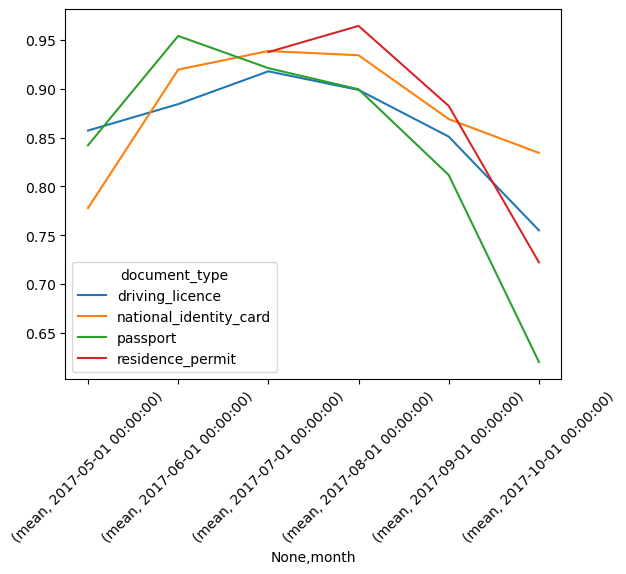

In [537]:
df.pivot_table(index='document_type', columns='month', values='pass_rate', aggfunc=['mean']).T.plot(rot=45)

`На графике видно, что нет такого, что какой-то один документ дает сбой. Пасспорт больше всего`

## pivot_table по issuing_country

In [567]:
top_countries = df['issuing_country'].value_counts().head(5).index
top_countries

Index(['GBR', 'FRA', 'LTU', 'ESP', 'IRL'], dtype='object', name='issuing_country')

In [569]:
(df[df['issuing_country'].isin(top_countries)].
 pivot_table(index='issuing_country', columns='month', values='pass_rate', aggfunc=['count', 'mean']))

count                                              \
month           2017-05-01 2017-06-01 2017-07-01 2017-08-01 2017-09-01   
issuing_country                                                          
ESP                      4         15         69         91         78   
FRA                      8         36        161        180        158   
GBR                     24         95        303        261        247   
IRL                      3         12         73         66         50   
LTU                      1         12         45         61         86   

                                 mean                                   \
month           2017-10-01 2017-05-01 2017-06-01 2017-07-01 2017-08-01   
issuing_country                                                          
ESP                     66      1.000   0.933333   0.942029   0.923077   
FRA                    252      0.750   0.916667   0.919255   0.955556   
GBR                    369      0.875   0.936842   0.924092   0.896552   
IRL                    109      1.000   1.000000   0.958904   0.878788   
LTU                    194      0.000   0.833333   0.888889   0.918033   

                                       
month           2017-09-01 2017-10-01  
issuing_country                        
ESP               0.833333   0.803030  
FRA               0.879747   0.821429  
GBR               0.801619   0.636856  
IRL               0.800000   0.669725  
LTU               0.837209   0.788660

<Axes: xlabel='None,month'>

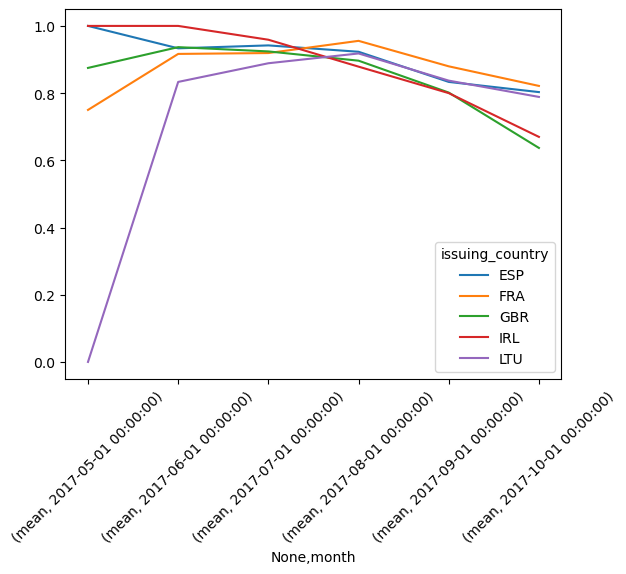

In [573]:
(df[df['issuing_country'].isin(top_countries)].
 pivot_table(index='issuing_country', columns='month', values='pass_rate', aggfunc=['mean'])).T.plot(rot=45)

`Здесь мы не можем сказать, что проблемы у какой то отдельной страны, т.к. маловато count. И опять же они все снижаются. В большей степени конечно GBR`

## pivot_table по gender

In [583]:
df.pivot_table(index='gender', columns='month', values='pass_rate', aggfunc=['count', 'mean'])

count                                                         \
month  2017-05-01 2017-06-01 2017-07-01 2017-08-01 2017-09-01 2017-10-01   
gender                                                                     
Female         20         80        270        292        298        425   
Male           29        146        560        574        520        738   

             mean                                                         
month  2017-05-01 2017-06-01 2017-07-01 2017-08-01 2017-09-01 2017-10-01  
gender                                                                    
Female   0.800000   0.925000   0.929630   0.934932   0.852349   0.731765  
Male     0.862069   0.945205   0.935714   0.907666   0.828846   0.715447

<Axes: xlabel='None,month'>

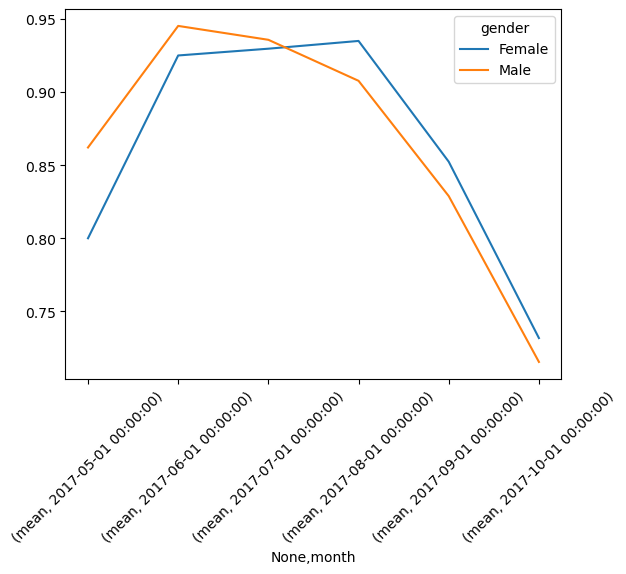

In [585]:
df.pivot_table(index='gender', columns='month', values='pass_rate', aggfunc=['mean']).T.plot(rot=45)